## Predicción de riesgo de hipertensión con Árboles de Decisión y KNN

En este notebook construirás y compararás dos modelos de clasificación (Árboles de Decisión y K-Vecinos más cercanos) para predecir si un paciente está en riesgo de sufrir hipertensión a partir de variables clínicas. A lo largo del proyecto realizarás un flujo completo de ciencia de datos, incluyendo exploración, preparación, modelado, evaluación e interpretabilidad.

En particular, desarrollarás los siguientes pasos:

Importar las librerías necesarias.

Cargar el conjunto de datos y realizar exploración y perfilamiento con pandas (nulos, duplicados, tipos, estadísticos).

Construir un pipeline de limpieza y preparación (justificando decisiones según el EDA).

Entrenar un Árbol de Decisión usando GridSearchCV con:

Entrenar un modelo KNN

Comparar en test los mejores modelos de cada algoritmo con: accuracy, recall, precision y F1.

Estimar un intervalo de confianza del 95% (bootstrapping) para al menos una métrica del mejor modelo.

Generar reglas interpretables del árbol de decisión con profundidad máxima de 3 para describir cuándo un paciente se considera en riesgo.

## Importación de librerías requeridas
Importaremos las librerías pandas, matplotlib, numpy y scikit-learn. En particular, usaremos las siguientes clases y funciones para entrenar y evaluar el modelo de KNN:

- Pipeline(): clase para construir el pipeline.
- SimpleImputer(): clase para realizar la imputación de datos.
- ColumnTransformer(): clase para realizar transformaciones por columnas.
- StandardScaler(), MinMaxScaler() y RobustScaler(): clases para realizar la estandarización.
- OneHotEncoder(): clase para realizar la codificación OneHot.
- DecisionTreeClassifier(): clase para crear el modelo de árbol de decisión.
- KNeighborsClassifier(): clase para crear el modelo de K-vecinos más cercanos.
- classification_report(): función para obtener un reporte con las métricas de rendimiento por clase.
- ConfusionMatrixDisplay(): clase para graficar la matriz de confusión.
- accuracy_score(): función para obtener la exactitud en un modelo de clasificación.
- precision_score(): función para obtener la precisión en un modelo de clasificación.
- recall_score(): función para obtener la sensibilidad en un modelo de clasifica

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler, OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.metrics import classification_report, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

## Carga de datos

Se realiza la carga de datos usando la función de Pandas read_csv()

In [3]:
df = pd.read_csv("Datos_hipertension.csv", sep=";", encoding="latin-1")

In [4]:
df.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
0,69,8.0,9,242.4,6.4,25.8,Ninguna,Si,Baja,No,127.8,Si,Si
1,32,11.7,10,177.2,5.4,23.4,Ninguna,No,Baja,No,105.9,No,No
2,78,9.5,3,193.0,7.1,18.7,Ninguna,No,Moderada,No,102.7,No,No
3,38,10.0,10,268.1,4.2,22.1,InhibidorACE,No,Baja,No,99.0,No,Si
4,41,9.8,1,175.3,5.8,16.2,Otro,No,Moderada,No,101.5,No,No


## Exploración del conjunto de datos
Utilizamos el medtodo head() y dtypes para tener una vista previa de los datos y las variables

In [4]:
df.dtypes

Edad                    int64
Ingesta_Sal           float64
Nivel_Stres             int64
Colesterol            float64
Duración_Sueño        float64
BMI                   float64
Medicación             object
Historia_Familiar      object
Actividad_Fisica       object
Fumador                object
Glucosa               float64
Enfermedad_Corazon     object
Hipertension           object
dtype: object

Como se puede observar el conjunto de datos contiene  variables categoricas: **Medicación**, **Historia_Familiar**, **Actividad_Fisica**, **Fumador**, **Enfermedad_Corazon**,  incluyendo nuestra variable objetivo **Hipertension**:
Por otro lado, se onserva que que la variable Ingesta_sal aparece como una variable numerica, sin embargo, en el diccionario de datos se define como una variable categorica (Bajo/Moderado/Alto) de tipo ordinal. Se podria realizar una discretización de esta variable, pero no conocemos los intervalos de discretizacion por lo que realizar esta transformación implicaría una categorización arbitraria y una pérdida de información de la variable original. En este caso y bajo estas condiciones, se opta por no utilizar esta variable dentro de los modelos.


Procederemos entonces a eliminar la variable Ingesta_Sal de nuestro dataset y puesteriormente volvemos a verificar que efectivamente haya sido eliminada

In [5]:
data = df.drop("Ingesta_Sal", axis=1)
data.columns

Index(['Edad', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño', 'BMI',
       'Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Glucosa', 'Enfermedad_Corazon', 'Hipertension'],
      dtype='object')

Utilizaremos df.describe() para obtener una descripción de las variables numéricas del conjunto de datos

In [6]:
df.describe()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Glucosa
count,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000,1990.000000
mean,50.379397,8.531608,4.974372,209.526935,6.452613,26.013869,105.642211
std,19.439669,1.994245,3.144396,75.791456,1.540354,4.507425,22.541122
min,18.000000,2.500000,0.000000,121.200000,1.500000,11.900000,70.000000
25%,34.000000,7.200000,2.000000,181.325000,5.400000,23.000000,89.200000
50%,50.000000,8.500000,5.000000,204.400000,6.500000,25.900000,102.500000
75%,67.000000,9.900000,8.000000,231.700000,7.500000,29.100000,119.875000
max,84.000000,16.400000,10.000000,2360.000000,11.400000,41.900000,196.100000


Con esta primera descripción de las variables numericas, se eviencia que algunas variables presentan outliers, en primer lugar el Nivel_colesterol con una media de 209.53 presenta un valor maximo de 2360 en el nivel de colesterol, lo cual es extremadamente grande si se tiene en cuenta que el nives limite alto para un adulto es de: 200 a 239 mg/dL segun se investiga"https://www.hopkinsmedicine.org/health/treatment-tests-and-therapies/lipid-panel?utm_source=chatgpt.com". Por otro lado va variable Duracion_sueño presente un valor minimo de 1.5 horas, lo cual es bastante bajo, además del BMI, que también presenta un valor minimo bastante bajo.

## Exploración de los datos

Se utilizará la variable data para almacenar un conjunto de datos modificado. Con esto, se tendra una copia de los datos originales almacenada en la variable data, por si en algún momento es necesario recuperar información que haya sido modificada.

In [7]:
data = df.copy()

### Tratamiento de nulos y duplicados
Ahora procederemos a verificar la cantidad de datos duplicados y datos faltantes; primero verifiquemos la presencia de duplicados

In [8]:
data.duplicated().sum()

np.int64(4)

Se puede observar que el dataset contiene 4 registros duplicados, por lo cual se procedera a eliminarlos

In [9]:
data = data.drop_duplicates()
data.duplicated().sum()

np.int64(0)

Ahora verificaremos si exiten datos faltantes en nuestro dataset con la función isnull().sum()

In [10]:
data.isnull().sum()

Edad                  0
Ingesta_Sal           0
Nivel_Stres           0
Colesterol            0
Duración_Sueño        0
BMI                   0
Medicación            0
Historia_Familiar     0
Actividad_Fisica      0
Fumador               0
Glucosa               0
Enfermedad_Corazon    0
Hipertension          0
dtype: int64

Genial, el conjunto de datos no tiene datos faltantes, esto nos ahora eltratamiento de datos nulos

### Exploración de variables numéricas
Ahora vamos a visualizar el comportamiento de las variables numericas se genera una grafica de distribución por cada variable numerica, teniendo asi que ninguna de las variables sigue una distribucion normal.

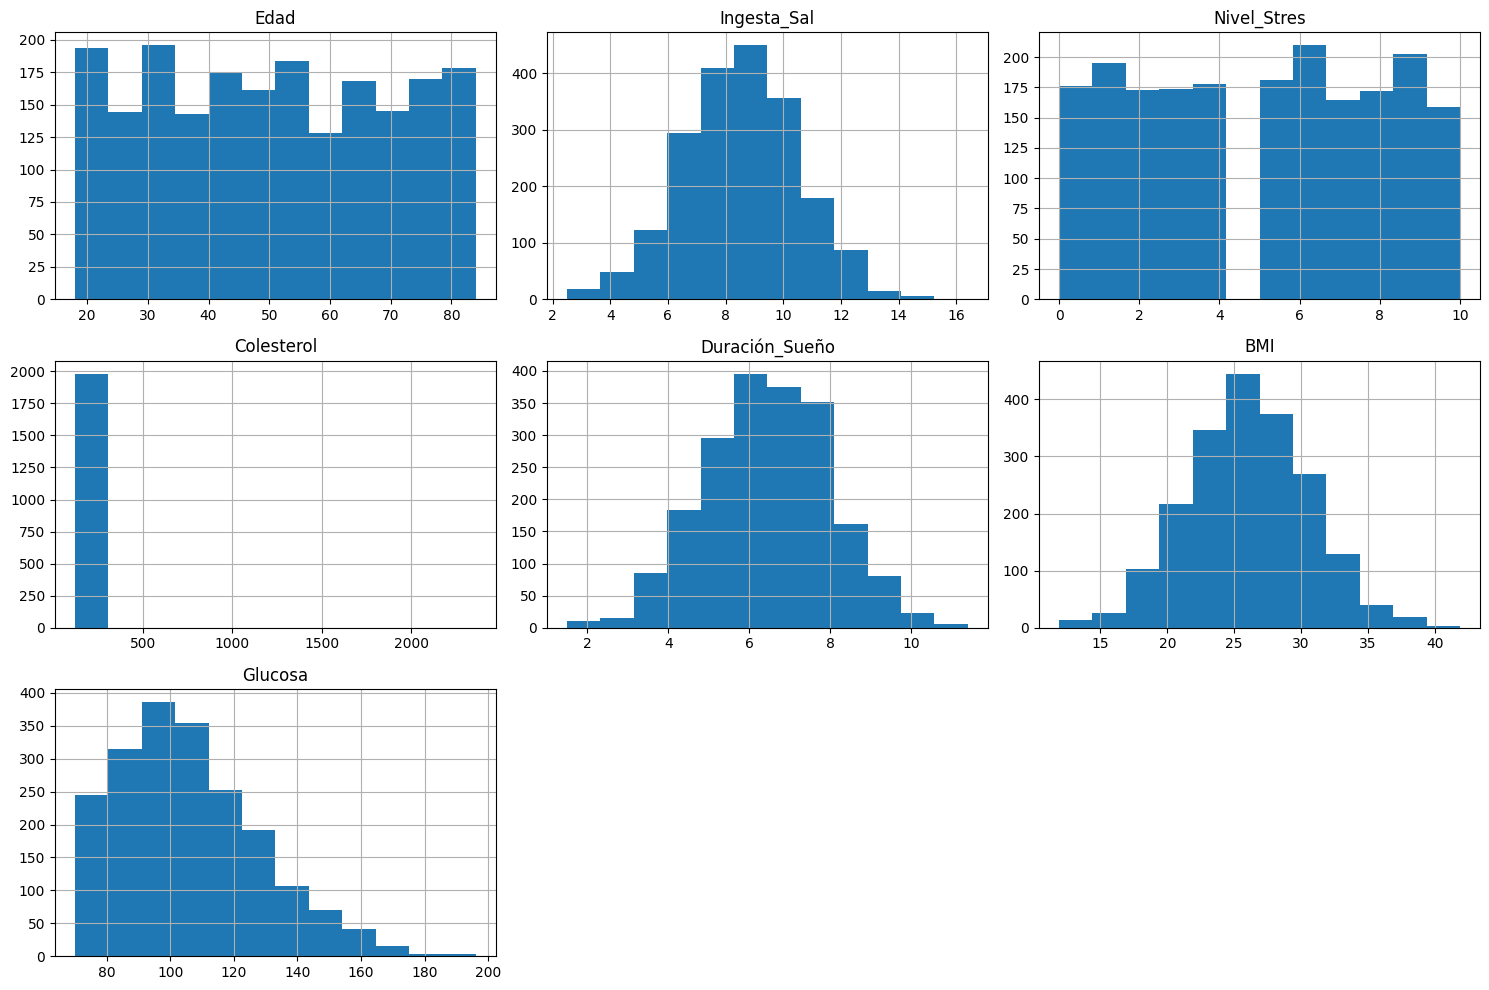

In [11]:
num_cols = data.select_dtypes(include=["int", "float"]).columns
data[num_cols].hist(bins=12, figsize=(15, 10))
plt.tight_layout()
plt.show()

Se puede observar que las variables Colesterol y Glucosa presentan un sesgo en su distribución, por ello se procedera a realizar un grafico de tipo box, para tener otra pespectiva del comportamiento de las variables numericas.

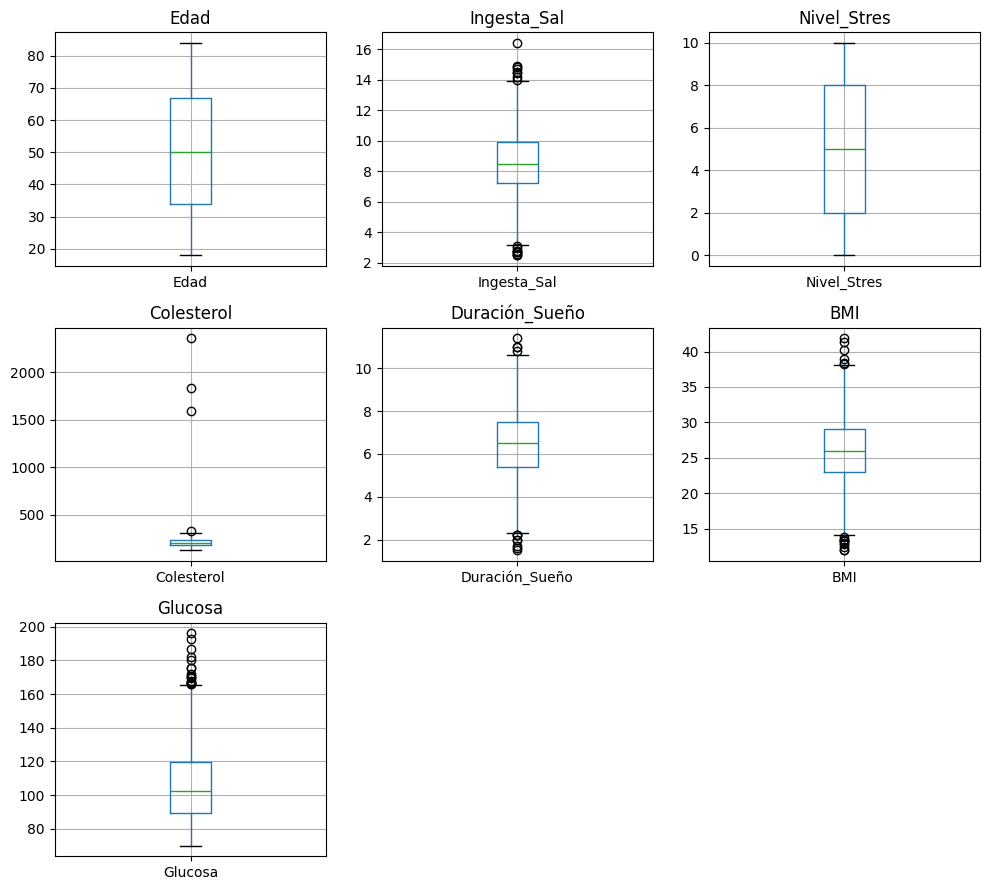

In [12]:
cols = num_cols
n = len(cols)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Sin duda el grafico Boxplot nos permite evidencias que las variables Ingesta_Sal, Duracion_Sueño IBM y Glucosa presentan outliers, sin embargo como se habia evidenciado desde el cuadro de descricción, la variable  Colesterol presente outliers con un rango muy marcado y si no son tratados, esto tendra un efecto negativo en los modelos de clasificacion.

Luego del respectivo analisis y de consultar la respuesta de los expertos en el foro se procedera a eliminar los outliers, daque se son muy pocos y su ausencia no afectaran la estimación del modelo, por otro lado se se manturievan como son valores extremadamente altos, podrian afectar los modelos. Para ello, se procede a calcular el primer y el tercer cuartil, los cuales son necesarios para determinar los límites de detección de valores atípicos. Además se utilizó el criterio de 1.5 veces el rango intercuartílico (IQR), conocido como regla de Tukey, para identificar valores atípicos. Este criterio establece límites por debajo del primer cuartil y por encima del tercer cuartil, permitiendo detectar observaciones inusualmente alejadas del centro de la distribución de manera robusta.

In [13]:
q1 = data["Colesterol"].quantile(0.25)
q3 = data["Colesterol"].quantile(0.75)
iqr = q3 - q1

lim_inf = q1 - 1.5*iqr
lim_sup = q3 + 1.5*iqr

data = data[(data["Colesterol"] >= lim_inf) & (data["Colesterol"] <= lim_sup)]

Ahora procederemos a realizar nuevamente el grafico de boxplot para ver como se ve la variable despues de la transformación

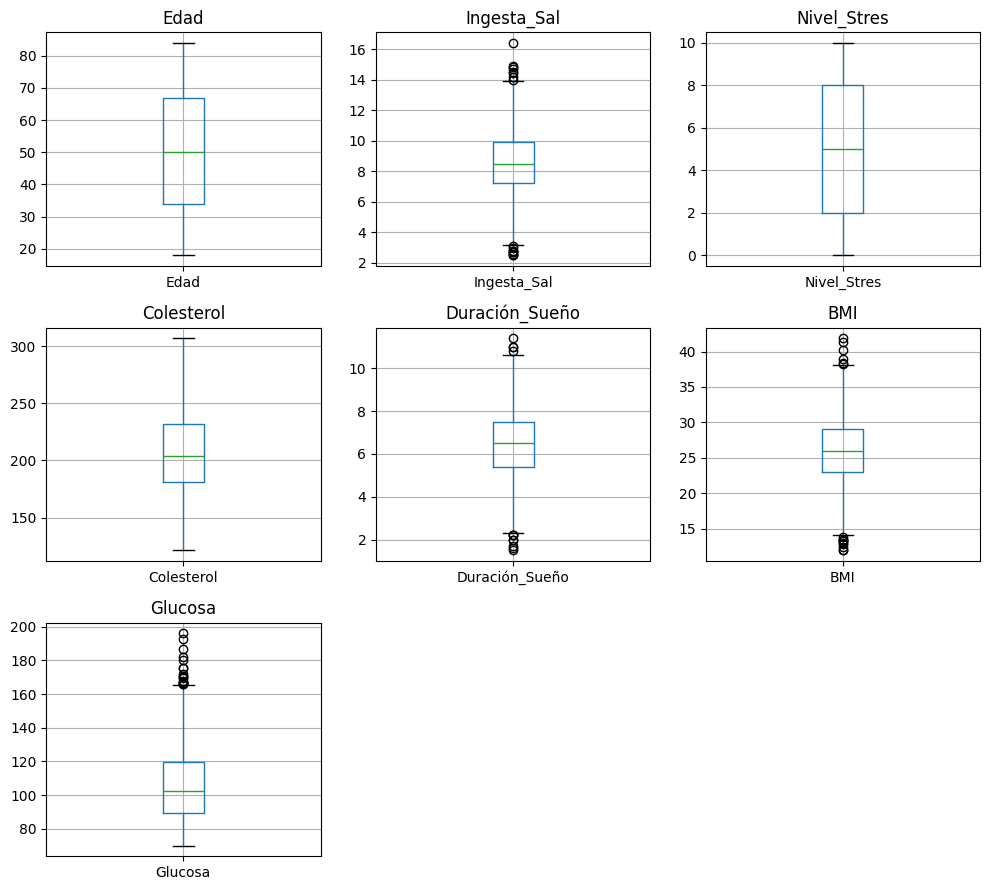

In [14]:
cols = num_cols
n = len(cols)

ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(10, 3*nrows))
axes = axes.flatten()

for i, col in enumerate(cols):
    data.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel("")

for j in range(i+1, len(axes)):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

Luego de eliminar los outliers se puede observar que la variable Colesterol ya presenta un comportamiento normal. Finalmente realizaremos un grafico de distribución para la variable colesterol para ver su comportamiento

Text(0.5, 1.0, 'Distribución de Colesterol')

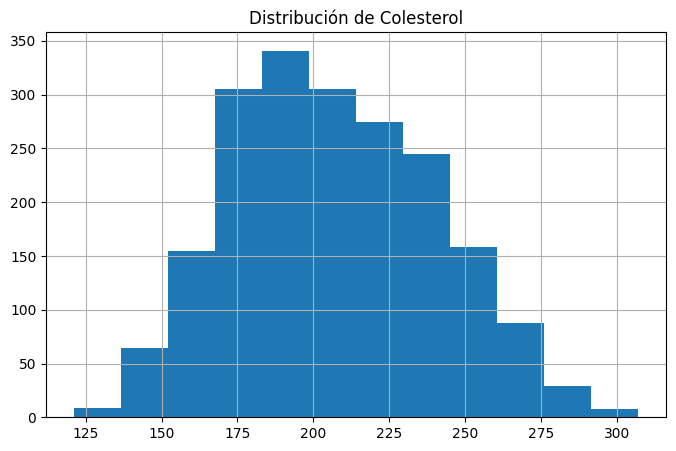

In [15]:
colesterol = data['Colesterol']
colesterol.hist(bins=12, figsize=(8, 5))
plt.title("Distribución de Colesterol")

### Exploración de variables categoricas
Ahora procederemos a realizar el analisis para las variables categoricas. Lo primero que vamos a calcular es la frcuencia para cada una de las clases de las variables categoricas

In [16]:
cat_cols = data.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"Value counts for {col}:")
    print(data[col].value_counts())
    print()

Value counts for Medicación:
Medicación
Ninguna           798
BloqueadorBeta    412
InhibidorACE      323
Diuretico         245
Otro              204
Name: count, dtype: int64

Value counts for Historia_Familiar:
Historia_Familiar
No    999
Si    983
Name: count, dtype: int64

Value counts for Actividad_Fisica:
Actividad_Fisica
Baja        935
Moderada    657
Alta        390
Name: count, dtype: int64

Value counts for Fumador:
Fumador
No    1414
Si     568
Name: count, dtype: int64

Value counts for Enfermedad_Corazon:
Enfermedad_Corazon
No    1507
Si     475
Name: count, dtype: int64

Value counts for Hipertension:
Hipertension
Si    1030
No     952
Name: count, dtype: int64



In [17]:
print(data['Hipertension'].value_counts())

Hipertension
Si    1030
No     952
Name: count, dtype: int64


Se puede observar que en general las clases no estan muy desbalanceadas, en particular la variable target Hipertension, lo cual es bueno a la hora de la clasificacion de los modelos.

## División de los datos
Antes de realizar los pasos para la transformación de los datos procederemos a dividir los datos de entrenamiento y prueba garantizando que las operaciones apliquen a los datos de train, antes de entrenar el modelo. Esto se realiza mediante la función train_test_spli() de sklearn. Para ello, tomaremos el 20% de los datos para test como una proporción recomendada, ademas utilizaremos un random_state de 77 según las recomendaciones del proyecto.

In [19]:
train, test = train_test_split(data, test_size=0.2, random_state=77)
train.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon,Hipertension
915,79,7.7,10,269.4,5.4,27.1,Otro,No,Baja,Si,107.8,Si,Si
609,27,8.8,7,198.9,6.8,25.4,Otro,Si,Moderada,No,113.9,No,Si
1964,49,5.7,6,184.5,6.6,26.4,BloqueadorBeta,No,Moderada,Si,88.8,Si,No
447,31,11.7,2,246.7,4.6,18.4,Ninguna,No,Moderada,Si,129.1,Si,Si
1119,72,12.2,8,290.1,4.9,24.0,BloqueadorBeta,No,Baja,No,136.4,No,Si


Además realizaremos la separación de la variable target "**Hipertension**" de nuestro conjunto de entrenamiento y validación y procederemos a validad los conjuntos x_train y x_test, para verificar que la variable target haya sido eliminada.

In [20]:
# Conjunto de entrenamiento
x_train = train.drop(["Hipertension"], axis=1)
y_train = train["Hipertension"]

# Conjunto de prueba
x_test = test.drop(["Hipertension"], axis=1)
y_test = test["Hipertension"]

In [21]:
x_train.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon
915,79,7.7,10,269.4,5.4,27.1,Otro,No,Baja,Si,107.8,Si
609,27,8.8,7,198.9,6.8,25.4,Otro,Si,Moderada,No,113.9,No
1964,49,5.7,6,184.5,6.6,26.4,BloqueadorBeta,No,Moderada,Si,88.8,Si
447,31,11.7,2,246.7,4.6,18.4,Ninguna,No,Moderada,Si,129.1,Si
1119,72,12.2,8,290.1,4.9,24.0,BloqueadorBeta,No,Baja,No,136.4,No


In [22]:
x_test.head()

,Edad,Ingesta_Sal,Nivel_Stres,Colesterol,Duración_Sueño,BMI,Medicación,Historia_Familiar,Actividad_Fisica,Fumador,Glucosa,Enfermedad_Corazon
1285,24,10.3,1,177.0,8.3,21.0,Diuretico,Si,Moderada,No,81.8,No
521,41,11.2,1,248.8,5.5,23.9,BloqueadorBeta,Si,Baja,Si,87.9,No
789,68,8.1,9,241.5,4.1,22.2,Ninguna,Si,Alta,No,110.6,No
171,28,6.6,8,211.2,7.5,29.4,Ninguna,Si,Moderada,No,83.5,No
44,61,7.6,5,222.5,4.3,18.9,InhibidorACE,Si,Moderada,No,120.2,Si


## Procesamiento de datos
En este etapa se realizara el procesamiento de las variables categoricas y numericas mediante flujos de transformación "**Pipelines**" de sklearn

Dado que la variabe target (Hipertension) no esta codifica y es una variable binaria, utilizaremos una codificación manual, quedando de la siguiente forma: No padece de Hipertencion = 0 y padece de Hipertension = 1. Se toma la desición de hacer el mapeo manual dado que no es una variable multiclase, en ese caso podria ser mejor usar OneHotEncoder.

In [23]:
map_y = {"No": 0, "Si": 1}
y_train = y_train.map(map_y).astype(int)
y_test = y_test.map(map_y).astype(int)

En este paso se separaran las variables numericas y categoricas mediante el metodo select_dtypes(), indicando que queremos incluir para la clase numerica las variables de tipo **int** y **float**, y para la case categorica especificando de deseamos incluir las variables de tipo **object**. Este paso es de suma importancia ya que dntro de los pipelines vamos a especificar que tipo de transformación vamos a aplicar a cada conjunto de variables

In [24]:
var_numeric = x_train.select_dtypes(include=["int", "float64"]).columns
var_categorical = x_train.select_dtypes(exclude=["int", "float64"]).columns

Como la implementación de los modelos de sklearn requiere que todas las variables sean nuemerias, realizaremos una codificación OneHot dentro de un pipeline mediante un objeto de la clase OneHotEncoder() y especificaremos que la salida no necesita manejo especial por dispersión con sparse_output=Falso

Ahora uniremos estos dos objetos en un solo paso del pipeline mediante un objeto de la clase **ColumnTransformer()**, especificando dos listas con los nombres de las variables numéricas y categóricas. Como la clase **ColumnTransformer()** va a agregar el nombre del paso ejecutado a cada variable, agregaremos el parametro verbose_feature_names_out=False,para evitar esto.

Utilizaremos también un objeto de la clase ColumnTransformer() para especificar el tipo de transformación que se usará con cada conjunto de variables, teniendo en cuenta este nuevo orden, y se incluira el parametro remainder = "passthruogh", indicando que las variables numericas no sa aplicara nunguna transformación.

In [25]:
encoder = OneHotEncoder(sparse_output=False)

tranformer = ColumnTransformer(
    transformers=[
        ("cat", encoder, var_categorical)
    ],
    remainder="passthrough"
)

## Búsqueda de hiperparámetros con un pipeline
Ahora crearemos un objeto de la clase **DecisionTreeClassifier()** que será nuestro modelo primer modelo base para realizar la búsqueda exhaustiva de hiperparámetros, especificando el parametro random_state = 77, como se especifico en el enunciado del proyecto.

In [26]:
decision_tree = DecisionTreeClassifier(random_state=77)

### Creación del pipeline
A continuación, se define la variable steps, la cual contiene la secuencia de pasos que conformaran el pipeline mediante tuplas de la forma (nombre, objeto). En primer lugar, se aplica el preprocesamiento de los datos mediante el transformador, encargado de codificar las variables categóricas. Posteriormente, se incorpora el modelo DecisionTreeClassifier(), que será entrenado con los datos transformados.

In [27]:
steps = [
    ("transformer", tranformer),
    ("model", decision_tree)
]   

En este paso definimos el objeto de la clase Pipeline con la secuencia definida en el paso anterior, y aplicamos el metodo .set_output(transform="pandas"), especificando que nuestra salida sera un DataFrame de pandas y no un arreglo de Numpy.

In [28]:
pipeline = Pipeline(steps).set_output(transform="pandas")
pipeline

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  Index(['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Enfermedad_Corazon'],
      dtype='object'))])),
                ('model', DecisionTreeClassifier(random_state=77))])

### Búsqueda de hiperparámetros
A continuación definiremos la variable param_grid que contiene los diccionarios sobre los cuales desamos realizar la busqueda.En este sentido, se presenta una breve descripción de los hiperparámetros considerados:

- criterion: el criterio de pureza, que determina la calidad de una división, en especifico la entropía y GINI.
- max_depth: que es la profundidad máxima del árbol. Este hiperparámetro es utilizado para el control de la complejidad del modelo.
- min_samples_split: número mínimo de datos necesarios en un nodo para poder definir una división.

Asimismo, en el pipeline los hiperparámetros del modelo se referencian mediante la estructura <paso>__<parámetro>, lo que permite especificar en param_grid el rango de búsqueda de cada uno de ellos.


In [29]:
param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth":[4,6,8,10,12],
    "model__min_samples_split": [3, 4, 5]
}

Asi mismo, definiremos un objeto de la clase `KFold()` para realizar la validación cruzada sobre 10 subconjuntos de datos

In [30]:
kfold = KFold(n_splits=10, shuffle=True, random_state=77)

Finalmente, definiremos la búsqueda mediante un objeto de la clase GridSearchCV() usando el pipeline constrido, el espacio de búsqueda param_grid, la metrica de evaliacuión, en nuestro caso el accuracy para determinar el mejor modelo y la técnica de validación cruzada kfold

In [31]:
grid = GridSearchCV(pipeline, param_grid, scoring='accuracy', cv=kfold)

A continuación, se aplica la búsqueda sobre el conjunto de entrenamiento. Durante este proceso, se ejecutaran las transformaciones definidas en el pipeline para cada partición generada en la validación cruzada.

In [32]:
grid.fit(x_train, y_train)

c:\Users\Lenovo\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\compose\_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


GridSearchCV(cv=KFold(n_splits=10, random_state=77, shuffle=True),
             estimator=Pipeline(steps=[('transformer',
                                        ColumnTransformer(remainder='passthrough',
                                                          transformers=[('cat',
                                                                         OneHotEncoder(sparse_output=False),
                                                                         Index(['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Enfermedad_Corazon'],
      dtype='object'))])),
                                       ('model',
                                        DecisionTreeClassifier(random_state=77))]),
             param_grid={'model__criterion': ['gini', 'entropy'],
                         'model__max_depth': [4, 6, 8, 10, 12],
                         'model__min_samples_split': [3, 4, 5]},
             scoring='accuracy')

Ahora obtendremos los mejores valores de los hiperparámetros usando `grid.best_params_`:

In [33]:
print("Best parameters:", format(grid.best_params_))

Best parameters: {'model__criterion': 'entropy', 'model__max_depth': 6, 'model__min_samples_split': 3}


Se puede observar que para el mejor modelo, se utiliza la entropía como criterio de pureza, una profundidad máxima de 6 y un mínimo de 3 datos para realizar una división. Además almacenaremos el mejor pipeline completo utilizando `grid.best_estimator_`:

In [34]:
mejor_modelo = grid.best_estimator_
mejor_modelo

Pipeline(steps=[('transformer',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  Index(['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Enfermedad_Corazon'],
      dtype='object'))])),
                ('model',
                 DecisionTreeClassifier(criterion='entropy', max_depth=6,
                                        min_samples_split=3,
                                        random_state=77))])

Para interpretar el modelo seleccionado, se extrajo la importancia de las variables desde el estimador final del pipeline. Como el preprocesamiento modifica la representación original de los datos, los nombres de las variables se recuperaron desde el transformador mediante get_feature_names_out(). Luego, se eliminan los prefijos automáticos remainder__ y cat__ generados por ColumnTransformer, con el fin de mejorar la legibilidad de los resultados. Posteriormente, se utiliza feature_importances_ del árbol de decisión para cuantificar la importnacia de cada variable, y se organiza la información de mayor a menor importancia.

In [35]:
variables = mejor_modelo.named_steps["transformer"].get_feature_names_out()
variables = [col.replace("remainder__", "").replace("cat__", "") for col in variables]

importancia = pd.DataFrame({
    "variables": variables,
    "importancia": mejor_modelo.named_steps["model"].feature_importances_
}).sort_values(by="importancia", ascending=False)

print(importancia)

                    variables  importancia
17                 Colesterol     0.732279
20                    Glucosa     0.128862
19                        BMI     0.027879
14                       Edad     0.020898
10                 Fumador_No     0.019541
12      Enfermedad_Corazon_No     0.013836
18             Duración_Sueño     0.011663
16                Nivel_Stres     0.011132
5        Historia_Familiar_No     0.007356
13      Enfermedad_Corazon_Si     0.007041
15                Ingesta_Sal     0.006443
11                 Fumador_Si     0.005060
6        Historia_Familiar_Si     0.004819
7       Actividad_Fisica_Alta     0.003192
4             Medicación_Otro     0.000000
2     Medicación_InhibidorACE     0.000000
1        Medicación_Diuretico     0.000000
0   Medicación_BloqueadorBeta     0.000000
3          Medicación_Ninguna     0.000000
9   Actividad_Fisica_Moderada     0.000000
8       Actividad_Fisica_Baja     0.000000


En el contexto de nuestro problema, los resultados mestran que los niveles de colesterol y glucosa son los factores que más influyen en la clasificación de un paciente con hipertensión. Asi mismo, variables como:  **índice de masa corporal (BMI)**, **la edad**, **el tabaquismo**, **Nivel_stres**, **Enfermedad_Corazon**, **antecedentes familiares**, **Duración del sueño** y **Actividad_Fisica**, también aportan información, aunque con menor peso. Por otro lado, la **Medicación** no aporta información al modelo.
Esto indica que el modelo reconoce principalmente patrones clínicos y metabólicos para identificar la presencia de hipertensión en los pacientes.

Para visualizar e interpretar el mejor modelo de árbol de decisión, se extrajo el estimador final del pipeline y se representa gráficament mediante la función plot_tree(). Se utilizaran los nombres de las variables transformadas para que las reglas de partición sen comprensibles, y se define las clases No y Si para identificar la categoría predicha en cada nodo. Asimismo, se limita la profundidad mostrada a tres niveles (max_depth=3) con el fin de facilitar la lectura del árbol y destacar las decisiones más relevantes del modelo.

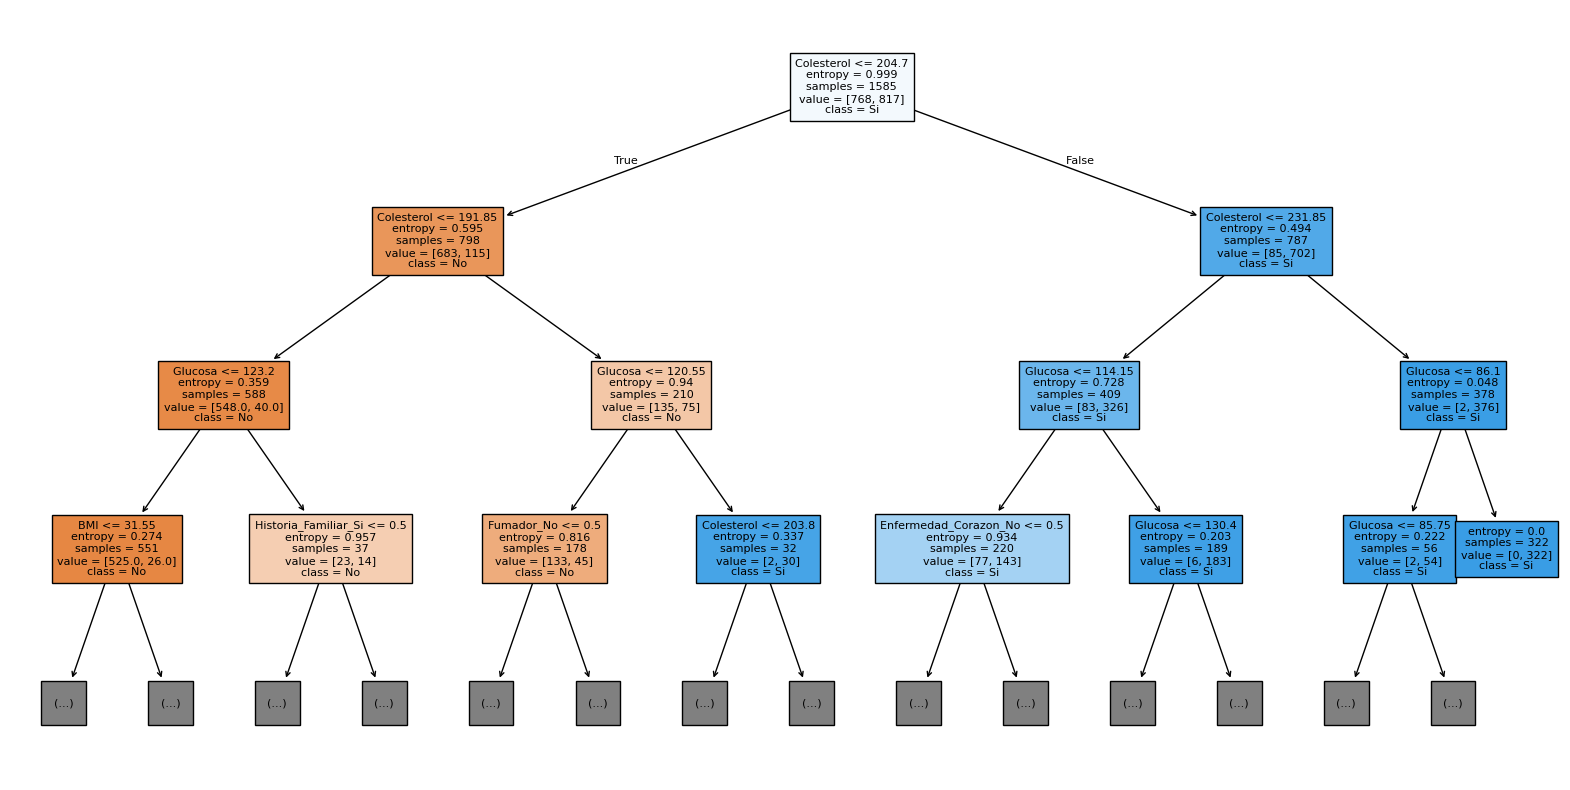

In [36]:
mejor_arbol = mejor_modelo.named_steps["model"]
plt.figure(figsize=(20, 10))
plot_tree(
    mejor_arbol,
    feature_names=variables,
    class_names=["No", "Si"],
    filled=True,
    fontsize=8,
    max_depth=3
)
plt.show()

## Evaluación del mejor modelo
A continuación se evaluara el mejor modelo mediante el metodo predict sobre los datos de test, aqui mejor_modelo representa el mejor pipeline y se aplicará la secuencia de pasos sobre el conjunto de test, y posteriormente se generan las predicciones correspondientes.

In [37]:
y_pred = mejor_modelo.predict(x_test)

A continuación, se genera la matriz de confusión para evaluar el desempeño del mejor modelo sobre el conjunto de prueba. Esta matriz permite identificar el número de casos clasificados correcta e incorrectamente en cada una de las clases de la variable Hipertensión, proporcionando una visión más detallada del comportamiento del modelo.

Text(0.5, 1.0, 'Matriz de Confusión')

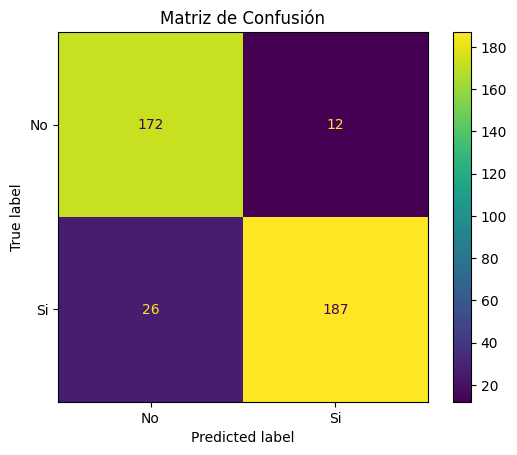

In [38]:
matrix = ConfusionMatrixDisplay.from_estimator(mejor_modelo, x_test, y_test, display_labels=["No", "Si"])
matrix.ax_.set_title("Matriz de Confusión")

De aa matriz de confusión podemos concluir que:
- Para la clase negativa, el modelo clasificó correctamente 172 verdaderos negativos, es decir, pacientes que no sufren de hipertensión y que fueron correctamente identificados por el modelo como pacientes sin hipertensión. Asimismo, se observaron 12 falsos positivos, correspondientes a pacientes que en realidad no sufren de hipertensión, pero que fueron clasificados por el modelo como si la tuvieran.

- Por otro lado, para la clase positiva, el modelo clasificó correctamente 187 verdaderos positivos, es decir, pacientes que efectivamente sufren de hipertensión y que fueron identificados adecuadamente por el modelo. Además, se presentaron 26 falsos negativos, que corresponden a pacientes que sí padecen hipertensión, pero que fueron clasificados por el modelo como si no la tuvieran.

En términos generales, estos resultados indican que el modelo presenta un buen desempeño en ambas clases, ya que la mayor parte de las observaciones fueron clasificadas correctamente. No obstante, el número de falsos positivos es mayor que el de falsos negativos, lo que sugiere que el modelo tiende a dejar pasar algunos casos reales de hipertensión. En el contexto del problema, este aspecto es importante, ya que no detectar pacientes hipertensos puede ser más delicado que clasificar erróneamente como hipertenso a un paciente sano.

Se presenta el reporte de clasificación para el modelo de árbol de decisión.

In [39]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.87      0.93      0.90       184
           1       0.94      0.88      0.91       213

    accuracy                           0.90       397
   macro avg       0.90      0.91      0.90       397
weighted avg       0.91      0.90      0.90       397



El reporte de clasificación evidencia que el modelo presenta un buen desempeño a nivel general, con una exactitud (accuracy) del 90%. Para la clase negativa, se observa una precisión de 0.87 y un recall de 0.93, lo que indica que el modelo identifica adecuadamente a la mayoría de los pacientes sin hipertensión. Para la clase positiva, correspondiente a pacientes con hipertensión, se obtuvo una precisión de 0.94 y un recall de 0.88, lo cual sugiere que, aunque el modelo es bastante confiable cuando predice hipertensión, aún deja sin detectar un 12% de los casos reales. En conjunto, el valor de F1-score cercano a 0.90 en ambas clases confirma un desempeño bastante equilibrado del modelo.

Finalmente, procederemos a calcular las metricas de calsificación que seran utilizadas el la tabla resumen, donde se comparará el desempeño de ambos modelos.

In [40]:
exactitud_tree = accuracy_score(y_test, y_pred)
precision_tree = precision_score(y_test, y_pred)
recall_tree = recall_score(y_test, y_pred)
f1_tree = f1_score(y_test, y_pred)

## 9. Pipeline para modelo KNN
Debido a que KNN clasifica a partir de distancias entre observaciones, es necesario escalar las variables numéricas para evitar que aquellas con mayor magnitud afecten el proceso de clasificación. Por esta razón, se incorpora un escalador dentro del pipeline. En primera instancia se utiliza RobustScaler, aunque posteriormente se comparará su desempeño con otros escaladores durante la búsqueda de hiperparámetros.

In [41]:
scaler = RobustScaler()
encoder_knn = OneHotEncoder(sparse_output=False)

transformer_knn = ColumnTransformer(
    transformers=[
        ("num", scaler, var_numeric),
        ("cat", encoder_knn, var_categorical)
    ]
)

Asi mismo, crearemos un objeto de la clase **KNeighborsClassifier()**  para realizar la búsqueda exhaustiva de hiperparámetros.

In [42]:
knn_model = KNeighborsClassifier()

### Creación del pipeline KNN
A continuación, se define la variable steps, la cual contiene la secuencia de pasos que conformaran el pipeline mediante tuplas de la forma (nombre, objeto). En primer lugar, se aplica el preprocesamiento de los datos mediante el transformador, encargado de escalar las variables numericas y codificar las variables categóricas. Posteriormente, se incorpora el modelo KNeighborsClassifier(), que será entrenado con los datos transformados.

In [43]:
steps = [
    ("transformer_knn", transformer_knn),
    ("model_knn", knn_model)
]

Nuevamente definimos el objeto de la clase Pipeline con la secuencia definida en el paso anterior, y aplicamos el metodo .set_output(transform="pandas"), especificando que nuestra salida sera un DataFrame de pandas y no un arreglo de Numpy.

In [44]:
pipeline = Pipeline(steps).set_output(transform="pandas")
pipeline

Pipeline(steps=[('transformer_knn',
                 ColumnTransformer(transformers=[('num', RobustScaler(),
                                                  Index(['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño',
       'BMI', 'Glucosa'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  Index(['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Enfermedad_Corazon'],
      dtype='object'))])),
                ('model_knn', KNeighborsClassifier())])

### Búsqueda de hiperparámetros del modelo KNN
A continuación, se define la variable param_grid_knn, la cual contiene los hiperparámetros del modelo y los valores que serán evaluados durante el proceso de búsqueda. En este caso, se considera el hiperparámetro:

- n_neighbors: número de vecinos más cercanos que el algoritmo toma en cuenta para realizar la clasificación de una nueva observación.


Asimismo, se incorpora al espacio de búsqueda el transformador aplicado a las variables numéricas dentro del ColumnTransformer, debido a que en el modelo KNN la escala de las variables influye directamente en el cálculo de distancias. Para ello, mediante la notación <paso>__<parámetro>, se evalúan como alternativas los escaladores StandardScaler(), MinMaxScaler() y RobustScaler(), con el fin de seleccionar la configuración que mejor se ajuste a los datos.

In [45]:
param_grid_knn = {
    "transformer_knn__num": [StandardScaler(), MinMaxScaler(), RobustScaler()],
    "model_knn__n_neighbors": [1, 2, 3, 4, 5]
}

Y definiremos un objeto de la clase `KFold()` para realizar la validación cruzada sobre 10 subconjuntos de datos

In [46]:
kfold = KFold(n_splits=10, shuffle=True, random_state=77)

Finalmente, definiremos la búsqueda mediante un objeto de la clase GridSearchCV() usando el pipeline constrido para el modelo KNN, el espacio de búsqueda param_grid, la metrica de evaliacuión, en nuestro caso el accuracy para determinar el mejor modelo y la técnica de validación cruzada kfold.

In [47]:
grid_knn = GridSearchCV(pipeline, param_grid_knn, scoring='accuracy', cv=kfold)

Y aplicamos la búsqueda sobre el conjunto de entrenamiento. Durante este proceso, se ejecutaran las transformaciones definidas en el pipeline para cada partición generada en la validación cruzada.

In [48]:
grid_knn.fit(x_train, y_train)

GridSearchCV(cv=KFold(n_splits=10, random_state=77, shuffle=True),
             estimator=Pipeline(steps=[('transformer_knn',
                                        ColumnTransformer(transformers=[('num',
                                                                         RobustScaler(),
                                                                         Index(['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño',
       'BMI', 'Glucosa'],
      dtype='object')),
                                                                        ('cat',
                                                                         OneHotEncoder(sparse_output=False),
                                                                         Index(['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Enfermedad_Corazon'],
      dtype='object'))])),
                                       ('model_knn', KNeighborsClassifier())]),
             param_grid={'model_knn__n_neighbors': [1, 2, 3, 4, 5],
                         'transformer_knn__num': [StandardScaler(),
                                                  MinMaxScaler(),
                                                  RobustScaler()]},
             scoring='accuracy')

Mostramos los mejores valores de los hiperparámetros usando `grid.best_params_`:

In [49]:
print("Best parameters:", format(grid_knn.best_params_))

Best parameters: {'model_knn__n_neighbors': 5, 'transformer_knn__num': StandardScaler()}


Se observa que la mejor combinación de hiperparámetros para el modelo KNN corresponde a n_neighbors = 5 y al uso de StandardScaler() como método de escalamiento. Esto indica que la clasificación de nuevas observaciones se realiza considerando los cinco vecinos más cercanos. Asimismo, aunque algunas variables presentaban valores atípicos y RobustScaler() suele ser una alternativa adecuada en esos casos, el proceso de búsqueda determinó que StandardScaler() ofrece el mejor desempeño para los datos analizados.

In [50]:
mejor_modelo_knn = grid_knn.best_estimator_
mejor_modelo_knn

Pipeline(steps=[('transformer_knn',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Edad', 'Ingesta_Sal', 'Nivel_Stres', 'Colesterol', 'Duración_Sueño',
       'BMI', 'Glucosa'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(sparse_output=False),
                                                  Index(['Medicación', 'Historia_Familiar', 'Actividad_Fisica', 'Fumador',
       'Enfermedad_Corazon'],
      dtype='object'))])),
                ('model_knn', KNeighborsClassifier())])

## Evaluación del mejor modelo
A continuación se evaluara el mejor modelo mediante el metodo predict sobre los datos de test, aqui mejor_modelo representa el mejor pipeline y se aplicará la secuencia de pasos sobre el conjunto de test, y posteriormente se generan las predicciones correspondientes.

In [51]:
pred = mejor_modelo_knn.predict(x_test)

A continuación, se genera la matriz de confusión para evaluar el desempeño del mejor modelo sobre el conjunto de prueba. Esta matriz permite identificar el número de casos clasificados correcta e incorrectamente en cada una de las clases de la variable Hipertensión, proporcionando una visión más detallada del comportamiento del modelo.

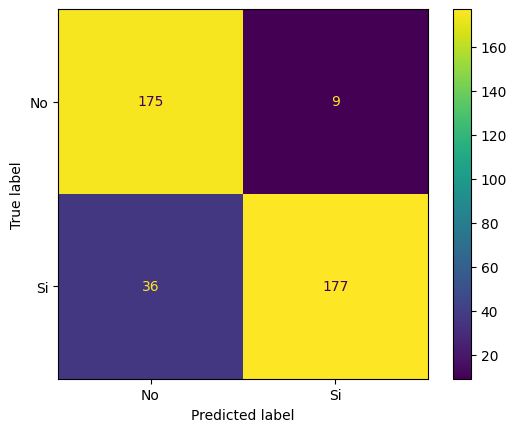

In [52]:
matrix = ConfusionMatrixDisplay.from_estimator(mejor_modelo_knn, x_test, y_test, display_labels=["No", "Si"])

De la matriz de confusión del modelo KNN se puede concluir que:
- Para la clase negativa, el modelo clasificó correctamente 175 verdaderos negativos, es decir, pacientes que no sufren de hipertensión y que fueron correctamente identificados por el modelo como pacientes sin hipertensión. Asimismo, se observaron 9 falsos positivos, correspondientes a pacientes que en realidad no sufren de hipertensión, pero que fueron clasificados por el modelo como si la tuvieran.

- Por otro lado, para la clase positiva, el modelo clasificó correctamente 177 verdaderos positivos, es decir, pacientes que efectivamente sufren de hipertensión y que fueron identificados adecuadamente por el modelo. Además, se presentaron 36 falsos negativos, que corresponden a pacientes que sí padecen hipertensión, pero que fueron clasificados por el modelo como si no la tuvieran.

En términos generales, estos resultados indican que el modelo presenta menor desempeño en cuanto a la clase positiva, mucho menor que el modelo de ábol de decisiós. En el contexto del problema, la cantidad de falsos positivos es un aspecto bastante importante, ya que no detectar pacientes hipertensos puede ser más delicado que clasificar erróneamente como hipertenso a un paciente sano.

Nuevamente se presenta el reporte de clasificación para el modelo KNN.

In [53]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.83      0.95      0.89       184
           1       0.95      0.83      0.89       213

    accuracy                           0.89       397
   macro avg       0.89      0.89      0.89       397
weighted avg       0.89      0.89      0.89       397



El reporte de clasificación muestra que el modelo presenta una exactitud general del 89%, lo que evidencia un buen desempeño global. Para la clase 0, correspondiente a pacientes sin hipertensión, se obtuvo una precisión de 0.83 y un recall de 0.95, lo que indica que el modelo identifica correctamente a la mayoría de los pacientes sanos. Para la clase 1, correspondiente a pacientes con hipertensión, se observó una precisión de 0.95 y un recall de 0.83, lo que sugiere que, cuando el modelo predice hipertensión, suele acertar con alta confiabilidad; sin embargo, aún queda sin detectar una proporción importante de casos reales. En conjunto, el F1-score de 0.89 en ambas clases confirma un desempeño equilibrado del clasificador.

Nuevamente calculamos las metricas de clasificación **exactitud, precision, recall y f1_score**  del modelo KNN para construir la tabla de resumen

In [54]:
exactitud_knn = accuracy_score(y_test, pred)
precision_knn = precision_score(y_test, pred)
recall_knn = recall_score(y_test, pred)
f1_knn = f1_score(y_test, pred)

Finalmente construimos la tabla resumen con las metricas de clasificación tanto para el árbol de decisión como para el modelo K-vecinos más cercanos, para ello generamos un DataFrame de pandas.

In [55]:
resumen =pd.DataFrame({
    'Modelo': ['Arbol de Decisión', 'KNN'],
    'Accuracy': [exactitud_tree, exactitud_knn],
    'Precision': [precision_tree, precision_knn],
    'Recall': [recall_tree, recall_knn],
    'F1-Score': [f1_tree, f1_knn]
})
print(resumen)

              Modelo  Accuracy  Precision    Recall  F1-Score
0  Arbol de Decisión  0.904282   0.939698  0.877934  0.907767
1                KNN  0.886650   0.951613  0.830986  0.887218


Al comparar ambos modelos, se observa que el árbol de decisión presenta el mejor desempeño global, con un accuracy de 0.904282, superior a la obtenida por KNN (0.886650). De igual manera, el árbol alcanza un F1-score de 0.907767, mientras que KNN registra 0.887218, lo que sugiere un mejor equilibrio entre precisión y recall.

En cuanto a la precisión, el modelo KNN obtiene un valor ligeramente superior (0.951613) frente al árbol de decisión (0.939698). Esto indica que, cuando KNN predice la clase positiva, es decir, hipertensión, suele clasificar con una proporción apenas mayor. Sin embargo, esta ventaja se acompaña de una reducción en la capacidad para identificar todos los casos positivos reales.

Lo anterior se refleja en el recall, donde el árbol de decisión alcanza 0.877934, superando al KNN, que obtiene 0.830986. En el contexto del problema, este resultado es especialmente relevante, ya que implica que el árbol detecta una mayor proporción de pacientes que realmente presentan hipertensión, mientras que KNN deja pasar más casos positivos, lo cual es muy grave en el campo medico.

En conjunto, aunque KNN muestra una precisión ligeramente mayor, el árbol de decisión ofrece un mejor desempeño integral, al combinar mayor exactitud, mejor recall y un F1-score superior. En conclusión, si el objetivo es contar con un modelo más equilibrado y con mayor capacidad para detectar pacientes hipertensos, el árbol de decisión se perfila como la mejor alternativa.

Aunque ambos modelos muestran desempeños similares, se elegiría el árbol de decisión por dos razones principales. En primer lugar, ofrece mejores resultados globales en accuracy, recall y F1-score, lo cual es especialmente importante en un problema clínico donde interesa detectar la mayor cantidad posible de pacientes con hipertensión. En segundo lugar, el árbol posee una mejor interpretabilidad, ya que permite identificar con claridad las reglas de decisión y las variables más influyentes en la clasificación. Esto resulta fundamental en contextos clínicos, donde la transparencia del modelo es un aspecto clave para respaldar su uso.

## Estimación de intervalos de confianza mediante Bootstrapping
El bootstrapping es una técnica estadística de remuestreo con reemplazo que se utiliza para estimar la distribución de una estadística cuando su distribución teórica no es conocida o resulta difícil de determinar.

En el contexto del aprendizaje automático, esta técnica es útil para evaluar la variabilidad de una métrica de desempeño por ejemplo, la exactitud (accuracy) a partir de múltiples muestras generadas desde el conjunto de prueba.

El procedimiento general consiste en:

Tomar una muestra aleatoria del conjunto de prueba con reemplazo.

Calcular la métrica de interés, en este caso, la exactitud.

Repetir este proceso un gran número de veces.

Construir una distribución empírica de los valores obtenidos para la métrica.

Estimar un intervalo de confianza del 95% a partir de los percentiles de dicha distribución.

Este enfoque permite analizar qué tan estable y confiable es el desempeño del modelo frente a variaciones en los datos, proporcionando una medida más robusta de su comportamiento esperado.

### Implementación del Bootstrapping
Para evaluar la estabilidad del modelo seleccionado, se aplicó la técnica de bootstrapping sobre el conjunto de prueba. Para ello, se generaron 1000 muestras aleatorias con reemplazo a partir de X_test y y_test, manteniendo en cada iteración el mismo tamaño del conjunto original.

En cada muestra, el mejor_arbol realiza las predicciones correspondientes y se calculó la métrica de exactitud (accuracy). Posteriormente, cada valor obtenido se almacenó en la lista scores, construyendo así una distribución empírica del desempeño del modelo.

In [56]:
n_bootstrap = 1000
scores = []

np.random.seed(77)

for i in range(n_bootstrap):

    indices = np.random.choice(len(x_test), size=len(x_test), replace=True)

    X_sample = x_test.iloc[indices]
    y_sample = y_test.iloc[indices]

    y_pred = mejor_modelo.predict(X_sample)

    score = accuracy_score(y_sample, y_pred)

    scores.append(score)


### Cálculo del intervalo de confianza

In [57]:
lower = np.percentile(scores, 2.5)
upper = np.percentile(scores, 97.5)

print("Intervalo de confianza (95%):")
print(lower, upper)

Intervalo de confianza (95%):
0.8740554156171285 0.9319899244332494


El intervalo de confianza del 95% obtenido mediante bootstrapping fue de 0.8741 a 0.9320, lo que indica que la exactitud del modelo se mantiene en un rango relativamente estrecho. Esto sugiere que el desempeño del modelo es estable y confiable frente a variaciones en los datos de prueba.

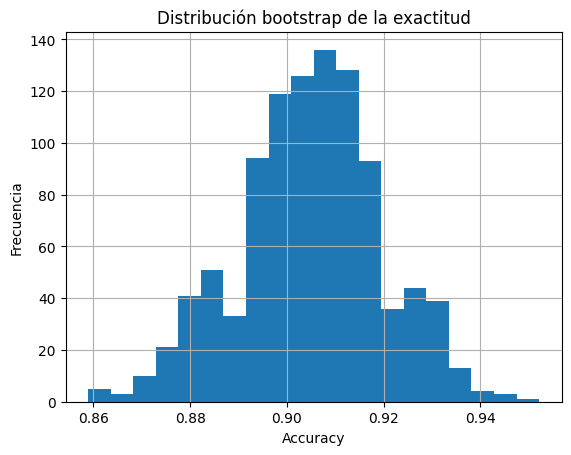

In [58]:
plt.hist(scores, bins=20)
plt.title("Distribución bootstrap de la exactitud")
plt.xlabel("Accuracy")
plt.ylabel("Frecuencia")
plt.grid(True)
plt.show()

La figura muestra la distribución de los valores de accuracy obtenidos mediante bootstrapping. Se observa que la mayoría de los resultados se concentran alrededor de 0.90, con una variabilidad relativamente baja. Esto sugiere que el modelo presenta un desempeño estable y consistente, ya que pequeñas variaciones en los datos de prueba no generan cambios importantes en la exactitud. En consecuencia, el intervalo de confianza estimado respalda la confiabilidad del modelo para la predicción del riesgo de hipertensión.

7. Utilizando el modelo de árboles de decisión, hasta con una profundidad de tres (3), genera las reglas que permitan determinar cuándo un paciente está en riesgo de sufrir hipertensión (no es necesario volver a construir el árbol).



Para facilitar la interpretación del modelo, se extrajo del pipeline el árbol de decisión seleccionado y se obtuvieron los nombres de las variables transformadas a partir del preprocesamiento aplicado. Dado que ColumnTransformer añade prefijos automáticos a los nombres de las variables, estos fueron eliminados con el fin de presentar reglas más claras y legibles. Posteriormente, mediante export_text(), se generó una representación textual del árbol limitada a los tres primeros niveles, lo que permitió visualizar de forma sencilla las reglas de decisión más importantes empleadas por el modelo.

In [59]:
mejor_arbol = mejor_modelo.named_steps["model"]

feature_names = mejor_modelo.named_steps["transformer"].get_feature_names_out()
feature_names = [col.replace("remainder__", "").replace("cat__", "") for col in feature_names]

tree_rules = export_text(
    mejor_arbol,
    feature_names=list(feature_names),
    max_depth=3
)

print(tree_rules)

|--- Colesterol <= 204.70
|   |--- Colesterol <= 191.85
|   |   |--- Glucosa <= 123.20
|   |   |   |--- BMI <= 31.55
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- BMI >  31.55
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Glucosa >  123.20
|   |   |   |--- Historia_Familiar_Si <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Historia_Familiar_Si >  0.50
|   |   |   |   |--- truncated branch of depth 3
|   |--- Colesterol >  191.85
|   |   |--- Glucosa <= 120.55
|   |   |   |--- Fumador_No <= 0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |   |--- Fumador_No >  0.50
|   |   |   |   |--- truncated branch of depth 3
|   |   |--- Glucosa >  120.55
|   |   |   |--- Colesterol <= 203.80
|   |   |   |   |--- class: 1
|   |   |   |--- Colesterol >  203.80
|   |   |   |   |--- truncated branch of depth 2
|--- Colesterol >  204.70
|   |--- Colesterol <= 231.85
|   |   |--- Glucosa <= 114.15
|   |   |   |--- Enfermedad_Co

**1. ¿Qué puedes decir de los valores de las métricas recall y precisión para cada una de las clases en cada modelo? ¿Cuál de estas métricas es más importante con base en la descripción del problema?**

En el árbol de decisión, la metricas de clasificación para positiva fueron altas (por ensima del 87%), esto indica que cuando el modelo clasifica un paciente con hipertensión suele acertar en la mayoría de los casos. Además, presentó un recall superior al de KNN para la clase positiva, lo cual significa que logró identificar una mayor proporción de pacientes que realmente padecen de hipertensión.

En el caso de KNN, las metricas de desempeño para la clase positiva fueron ligeramente manenor que la del árbol, a ecepción de la precisión en la cual el modelo KNN tuvo un mejor desempeño con aproximadamente un 95% de precisión para la calse positiva. Esto sugiere que las predicciones positivas son muy confiables. Sin embargo, su recall fue menor, por lo que dejó pasar más pacientes que sí tenían hipertensión, lo cual es tiene un impacto significativo ya que se esta dejendo de clasificar el 4.7% de pacientes con Hipertención en comparación con el modelo de álbol de decisión., 

Para la clase negativa, ambos modelos mostraron un buen desempeño, aunque KNN presentó una capacidad ligeramente mayor para reconocer pacientes sin hipertensión. No obstante, en este problema la métrica más importante es el recall de la clase positiva, ya que en un contexto clínico resulta más grave no detectar a un paciente hipertenso que clasificar erróneamente a un paciente sano como hipertenso. En otras palabras, sería preferible reducir los falsos negativos.

2. **¿Consideras que el rendimiento de los modelos es adecuado? Si no es así, ¿cómo podrían mejorarse los resultados?**

En términos generales, el rendimiento de ambos modelos puede considerarse adecuado, ya que presentan valores altos de exactitud, precisión, recall y F1-score. Ambos clasificadores logran un desempeño cercano al 90%, lo cual indica una capacidad para clasificar aceptable en el contexto del problema planteado.

Sin embargo, aún existe margen de mejora, especialmente en la detección de casos positivos reales. Los resultados podrían mejorarse de varias maneras: ampliando un espacio mas amplio de búsqueda de hiperparámetros, probando otros algoritmos de clasificación. De manera particular, retirar las variables que no aportan información al modelo de árbol de decición podria mejorrar el ajuste y reducir la complejidad del modelo. Por otro lado un mejor tratamiento de outliers, podría darle un mejor desempeño almodo. Finalmente, probar con otros modelos como las redes neuronales, ayudaria a reducir la brecha en el error de los modelos planteados.

**3. ¿Cuáles son las variables más significativas según el mejor modelo basado en árboles de decisión? Reflexiona sobre cómo este nuevo conocimiento podría ayudar a tomar decisiones en el contexto del problema.**

Según el árbol de decisión, las variables más significativas fueron principalmente Colesterol, seguida por Glucosa, BMI, Edad, Nivel de estrés, tabaquismo e historia familiar. En particular, el colesterol destacó con una importancia muy superior al resto, esto nos indica que fue el factor más influyente en las reglas de clasificación del modelo.

Este hallazgo es bastante útil en el contexto clínico, ya que permite identificar qué factores están más relacionados con la presencia de hipertensión en los datos analizados. Desde un punto de vista práctico, esta información podría orientar estrategias de prevención, seguimiento y priorización de pacientes. Por ejemplo, si colesterol y glucosa aparecen como variables dominantes, podrían considerarse indicadores especialmente relevantes para reforzar el monitoreo clínico y la detección temprana de riesgo cardiovascular.

**4. Si ambos modelos presentan resultados similares en las métricas de desempeño, ¿cuál seleccionarías considerando el contexto clínico del problema? Justifica tu elección.**

Por supuesto seleccionaría el árbol de decisión. Aunque ambos modelos presentan resultados cercanos, el árbol mostró mejor accuracy, mejor recall y mejor F1-score que KNN, lo cual resulta especialmente importante en un problema clínico donde interesa detectar la mayor cantidad posible de pacientes con hipertensión.

Además, el árbol de decisión ofrece una ventaja adicional: su interpretabilidad. A diferencia de KNN, permite visualizar las reglas de decisión y conocer más claramente cuáles variables son más relevantes a la hora de clasificar un paciante con Hipertension. En el contexto clínico, esta interpretabilidad es sumamnete valiosa porque no solo importa predecir bien, sino también comprender y justificar el criterio utilizado por el modelo. Por ello, el árbol de decisión representa una opción más adecuada tanto por desempeño como por interpretabilidad.

**5. ¿Qué indica el intervalo de confianza estimado sobre la estabilidad y confiabilidad del modelo seleccionado?**

El intervalo de confianza estimado mediante la tecnica de bootstrapping permite evaluar la variabilidad en el desempeño del modelo. Como el intervalo obtenido para la métrica seleccionada, en este caso la exactitud, es relativamente estrecho, esto sugiere que el rendimiento del modelo es estable frente a distintas muestras y que sus resultados son confiables. En otro caso, si el intervalo es muy amplio indicaría mayor incertidumbre y variabilidad en el modelo.

En este contexto, el intervalo de confianza del 95% puede interpretarse como un rango plausible, donde se espera que se encuentre el desempeño real del modelo. Por lo tanto, si el intervalo de confianza alrededor de la exactitud del árbol de decisión no es demasiado amplio, puede concluirse que el modelo no solo tiene buen rendimiento en la muestra analizada, sino que también mantiene una capacidad predictiva relativamente consistente, demostrando asi su utilidad como herramienta de apoyo en la clasificación de pacientes con hipertensión.